In [1]:
# This notebook shows the implementation of a trigram model (part of makemore's exercise)

In [2]:
words = open("names.txt", "r").read().splitlines()

In [3]:
min(len(word) for word in words)

2

In [4]:
max(len(word) for word in words)

15

In [5]:
# getting all the charecters that are unique in the names dataset
chars = list(sorted(set("".join(words))))
# each characters associated with an index to later create a probability matrix out of it.
stoi = {s:i+1 for i,s in enumerate(chars)}
# add . as it's a special token used to denote start and end of word.
stoi['.'] = 0
# reverse stoi list to get i that maps to its respective s
itos = {i:s for s,i in stoi.items()}

In [6]:
len(chars)

26

In [7]:
import torch

In [8]:
pmatrx = torch.zeros((27, 27), dtype=torch.int32)

In [12]:
# padding with tokens to indicate start and end words.
for w in words:
    char = ['.'] + list(w) + ['.']
    for c1, c2 in zip(char, char[1:]):
        ix1 = stoi[c1]
        ix2 = stoi[c2]
        pmatrx[ix1, ix2] += 1

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline

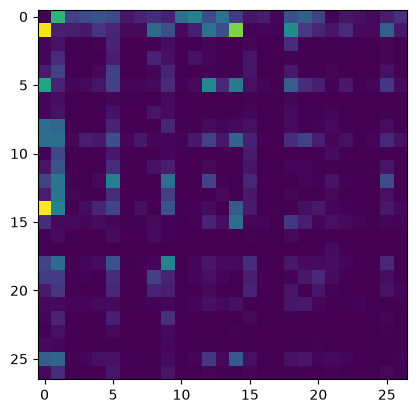

In [15]:
plt.imshow(pmatrx)

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

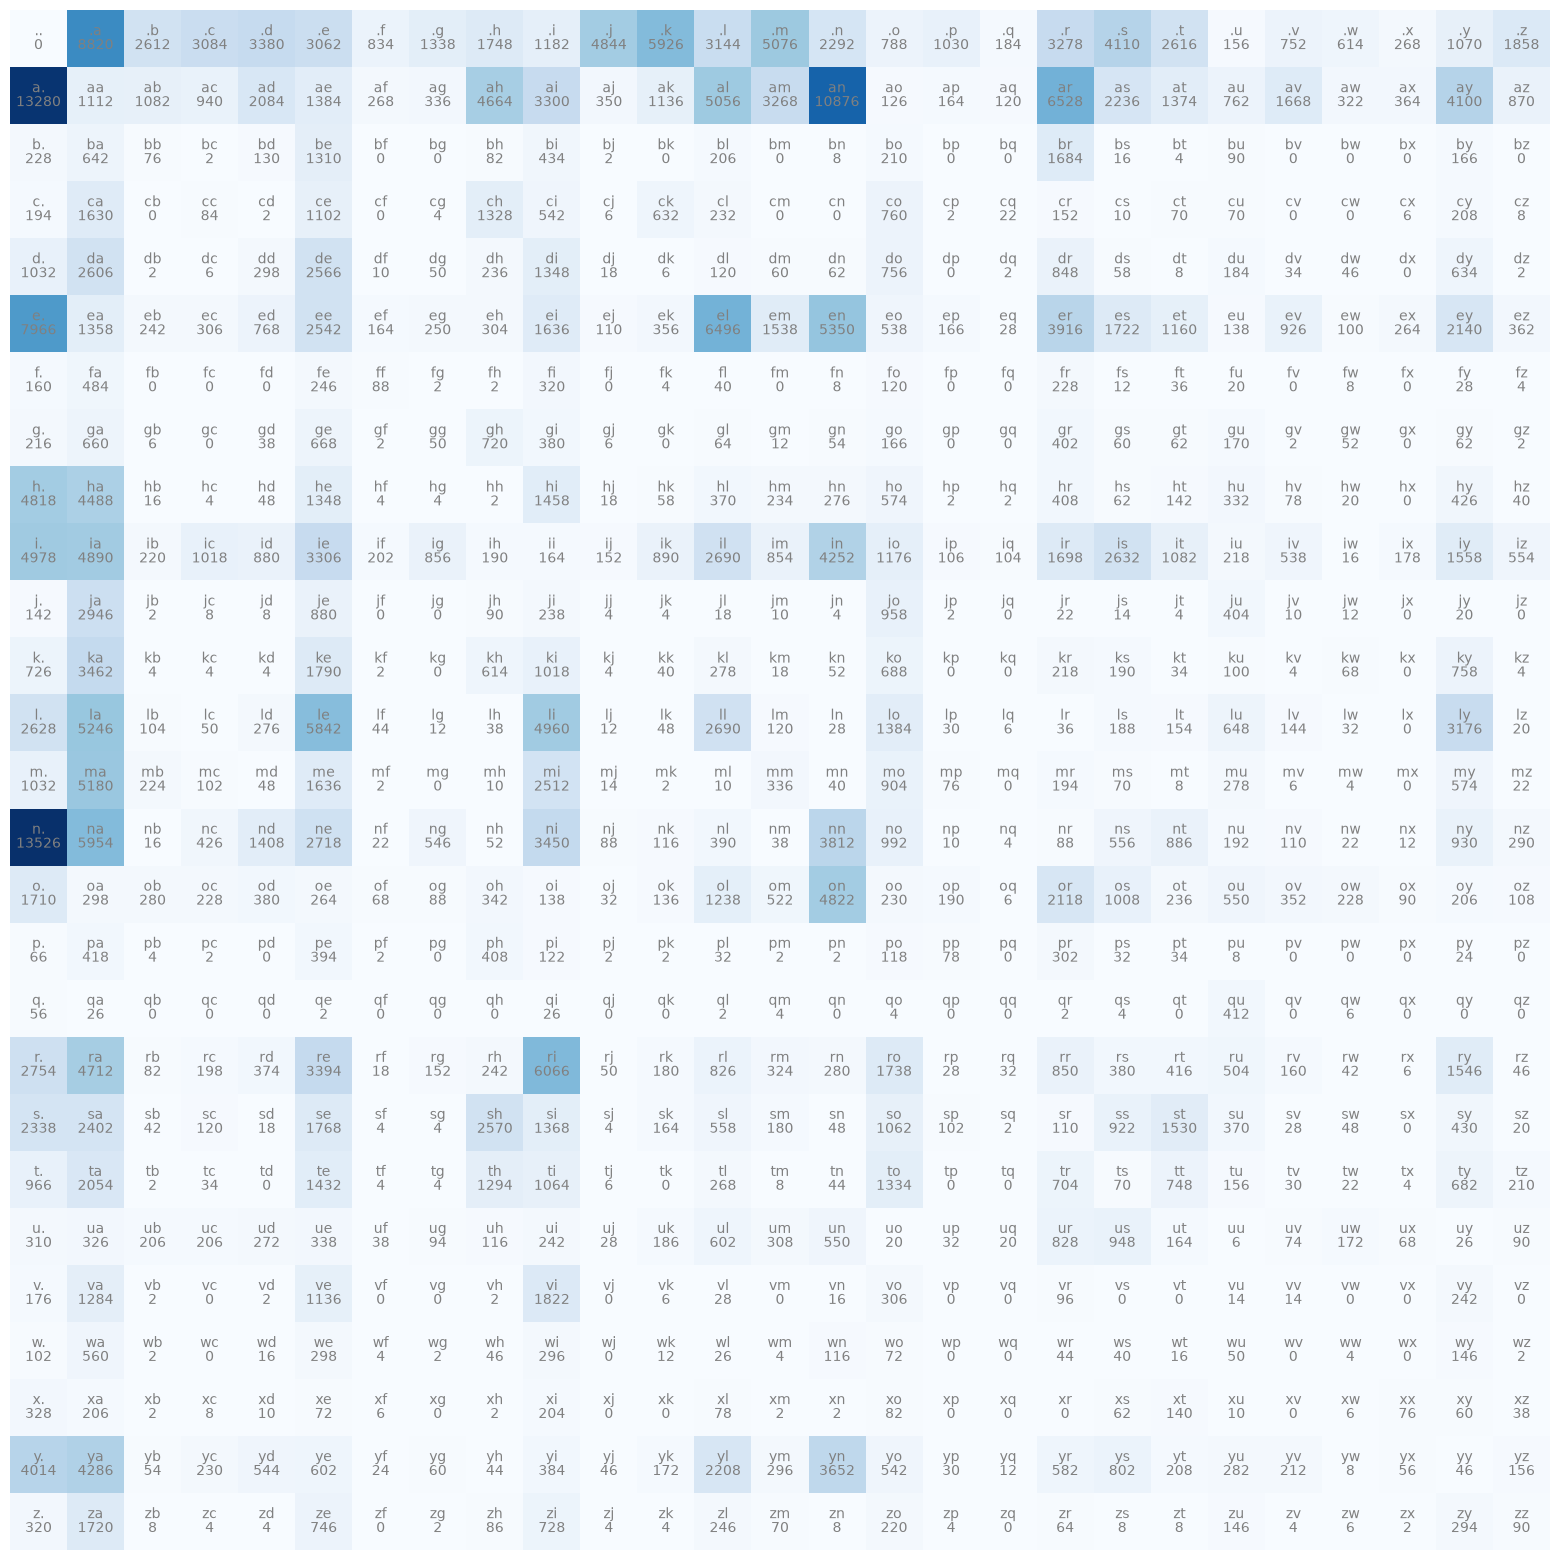

In [17]:
plt.figure(figsize=(20, 20))
plt.imshow(pmatrx, cmap="Blues")
for i in range(27):
    for j in range(27):
        st = itos[i] + itos[j]
        plt.text(j, i, st, ha="center", va="bottom", color="gray")
        plt.text(j, i, pmatrx[i, j].item(), ha="center", va="top", color="gray")
plt.axis('off')

tensor([   0, 8820, 2612, 3084, 3380, 3062,  834, 1338, 1748, 1182, 4844, 5926,
        3144, 5076, 2292,  788, 1030,  184, 3278, 4110, 2616,  156,  752,  614,
         268, 1070, 1858], dtype=torch.int32)

In [10]:
# neural network approach